### Customer Churn Predictor

Pobranie i załadowanie danych

In [1]:
import os
import kagglehub
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

c:\Users\patry\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
file_path = kagglehub.dataset_download('gauravtopre/bank-customer-churn-dataset')
print(f'File path: {file_path}')

files = os.listdir(file_path)
print(files)

File path: C:\Users\patry\.cache\kagglehub\datasets\gauravtopre\bank-customer-churn-dataset\versions\1
['Bank Customer Churn Prediction.csv']


In [3]:
csv_path = os.path.join(file_path, files[0])
print(csv_path)

C:\Users\patry\.cache\kagglehub\datasets\gauravtopre\bank-customer-churn-dataset\versions\1\Bank Customer Churn Prediction.csv


In [4]:
data = pd.read_csv(csv_path)
print(data.info())
data

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customer_id       10000 non-null  int64  
 1   credit_score      10000 non-null  int64  
 2   country           10000 non-null  object 
 3   gender            10000 non-null  object 
 4   age               10000 non-null  int64  
 5   tenure            10000 non-null  int64  
 6   balance           10000 non-null  float64
 7   products_number   10000 non-null  int64  
 8   credit_card       10000 non-null  int64  
 9   active_member     10000 non-null  int64  
 10  estimated_salary  10000 non-null  float64
 11  churn             10000 non-null  int64  
dtypes: float64(2), int64(8), object(2)
memory usage: 937.6+ KB
None


,customer_id,credit_score,country,gender,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn
0,15634602,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,15647311,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,15619304,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,15701354,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,15737888,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0
...,...,...,...,...,...,...,...,...,...,...,...,...
9995,15606229,771,France,Male,39,5,0.00,2,1,0,96270.64,0
9996,15569892,516,France,Male,35,10,57369.61,1,1,1,101699.77,0
9997,15584532,709,France,Female,36,7,0.00,1,0,1,42085.58,1
9998,15682355,772,Germany,Male,42,3,75075.31,2,1,0,92888.52,1


### 2. Preprocessing

Czyszczenie danych, uzupełnianie braków, zamiana wartości kategorycznych, EDA

In [12]:
cols_missing_val = data.isnull().sum()
print(cols_missing_val)

customer_id         0
credit_score        0
country             0
gender              0
age                 0
tenure              0
balance             0
products_number     0
credit_card         0
active_member       0
estimated_salary    0
churn               0
dtype: int64


Wniosek: Nasz df nie zawiera brakujących danych.

In [11]:
# Chcę policzyć ile jest różnych wartości w kategorycznych kolumnach
categorical_cols = data.select_dtypes(include=['object']).columns
unique_categ_cols = data[categorical_cols].nunique()
print(unique_categ_cols)

country    3
gender     2
dtype: int64


Wniosek: Ze względu na małą ilość unikalnych wartości w kolumnach kategorycznych, możemy śmiało zastosować OneHotEncoding.

<Axes: xlabel='churn', ylabel='count'>

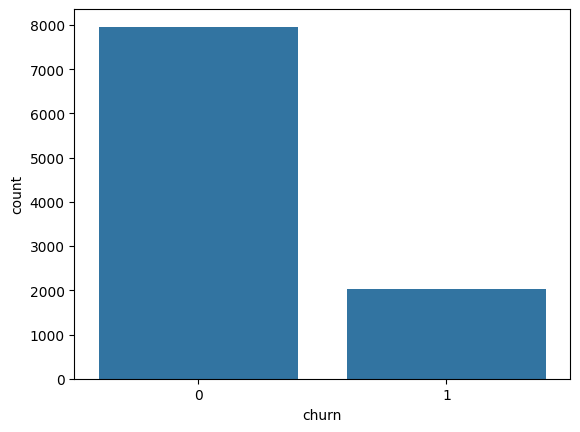

In [ ]:
# Chcę zobaczyć rozkład wartości w kolumnie 'churn'
sns.countplot(x='churn', data=data)

Wniosek: Ze względu na wysoki poziom niezbalansowania klas (klientów odchodzących jest dużo mniej) musimy uważać podczas dzielenia danych na treninowe i testowe.